# Hands-On AI for Science
## August 13, Afternoon: Embeddings for Scientific Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhasegaw/hands_on_ai_for_science/blob/main/lectures/colab/a13pm_embeddings_colab.ipynb)

**No Python installed?** Click the badge above to open a self-contained version of this notebook in Google Colab.  It runs in your browser, with nothing to download and nothing to install.

In the last session, word embeddings were built by hand: each word got a vector, and the vectors were nudged until words appearing in similar contexts ended up with similar vectors.

This session makes one central claim: **that idea is not about words.**  The same principle is the operating principle behind some of the most useful models in modern science. *Entities that occur in similar contexts end up with similar vectors*. 

In this lecture we will work with two embedding spaces that were trained by someone else (one for English words, one for proteins). We will practice the standard ways of interrogating such a space: nearest neighbors, low-dimensional projection, distance-matrix comparison, and linear probing.

## Setup

Before anything else, the cell below checks that every package this notebook needs is available, and that the data and homework files included with the repository are present. A MISSING file usually means Jupyter was started in the wrong folder. It should be started in the repository's `lectures` folder.  **If anything prints MISSING, install it now, before going further** — debugging a missing package mid-session is far more disruptive than installing it up front.  With Anaconda, the only package likely to be missing is `umap-learn`; it is installed by opening a terminal and running:

```
pip install umap-learn
```

One important habit: **after installing anything, restart the kernel** (Kernel → Restart Kernel) and re-run the notebook from the top.  A running Python session that predates an installation can misbehave in confusing ways, even when the installation itself succeeded.

In [18]:
import importlib.util, os

packages = ['numpy', 'pandas', 'matplotlib', 'scipy', 'sklearn', 'umap']
files = ['protein_localization.csv', 'protein_embeddings.npy', 'word_vectors_50d.npz', 'a13pm_hw2.py']

for pkg in packages:
    print(f'{pkg:30s}', 'OK' if importlib.util.find_spec(pkg) is not None else 'MISSING')
for f in files:
    print(f'{f:30s}', 'OK' if os.path.exists(f) else 'MISSING')

numpy                          OK
pandas                         OK
matplotlib                     OK
scipy                          OK
sklearn                        OK
umap                           OK
protein_localization.csv       OK
protein_embeddings.npy         OK
word_vectors_50d.npz           OK
a13pm_hw2.py                   OK



1. [The principle](#principle)
1. [The same idea in other domains](#domains)
1. [Word embeddings, revisited](#words)
1. [Vector arithmetic](#arithmetic)
1. [Protein embeddings](#proteins)
1. [Projection to two dimensions](#projection)
1. [Comparing distance matrices](#rsa)
1. [Linear probes](#probes)
1. [Homework](#homework)
1. [Summary](#summary)

<a id="principle"></a>

## 1. The principle

Stated without any reference to language, the word2vec recipe was:

1. Represent each entity as a vector.
2. Define "context": what tends to appear around an entity.
3. Change vectors so that entities with similar contexts become similar vectors.

Nothing in those three steps mentions words.  Words were the example and the inspiration for the idea. But the idea generalizes.  What is learned is a **representation**: a coordinate system in which *distance means something*. Nearby entities behave alike.  Once data is in such a space, familiar tools apply: distances, projections, correlations, classifiers.  That is what makes embeddings useful for science, and it is what the rest of this session demonstrates.

<a id="domains"></a>

## 2. The same idea in other domains

| Entity | "Context" is... | Example model family |
|---|---|---|
| word | the surrounding words | word2vec, GloVe |
| protein / amino acid | the surrounding residues | ESM, ProtTrans |
| gene | co-expression across conditions | gene2vec |
| cell | its expression profile | scVI, Geneformer |
| *any entity* | *whatever it co-occurs with* | ... |

The last row is the generalized rule.  Embedding models form the basis of language models and large language models. But embedding models also now exist for molecules, medical images, animal vocalizations, astronomical spectra, and clinical records.  Whenever entities occur in measurable contexts, this method can be applied. And, increasingly, someone has already applied it and published the trained model.  Using such a model well requires knowing how to *examine* the space it produces. That is the skill this hour is about.

<a id="words"></a>

## 3. Word embeddings, revisited

The embeddings built in the last session were trained on a toy corpus of a few dozen tokens.  Professionally trained word embeddings come from billions of words.  The file `word_vectors_50d.npz` (41 KB, a part of this workshop repository) contains a small curated subset of **GloVe** word vectors. These are 50-dimensional embeddings for words, trained on 6 billion words of text (Pennington, Socher & Manning, 2014):

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

z = np.load('word_vectors_50d.npz')
words = [str(w) for w in z['words']]
word_vecs = z['vectors']
print(len(words), 'words, each a vector of length', word_vecs.shape[1])

221 words, each a vector of length 50


The most basic way to examine an embedding space is to pick an entity and ask **who its neighbors are**.  Distance is usually measured with *cosine distance* (from `scipy.spatial.distance`, seen briefly yesterday). As a reminder, this is the cosine of the angle between the two vectors in the 50-dimensional space. Two vectors that point in the exact same direction will have an angle of 0, and so a cosine of 1. Vectors that are orthogonal (uncorrelated) will have an angle of 90 degrees, and so a cosine of 0. One detail to keep straight: scipy computes cosine *distance*, which is 1 minus the cosine. So in the outputs below, a distance near 0 means "pointing the same direction," and a distance near 1 means "unrelated."

In [2]:
word_dist = squareform(pdist(word_vecs, 'cosine'))

def word_neighbors(w, k=5):
    i = words.index(w)
    order = [j for j in np.argsort(word_dist[i]) if j != i]
    return [words[j] for j in order[:k]]

for w in ['dog', 'france', 'doctor', 'gene', 'king']:
    print(f'{w:8s} ->', word_neighbors(w))

dog      -> ['cat', 'horse', 'pig', 'snake', 'boy']
france   -> ['paris', 'spain', 'italy', 'germany', 'canada']
doctor   -> ['nurse', 'patient', 'teacher', 'father', 'mother']
gene     -> ['brain', 'protein', 'cell', 'cancer', 'mouse']
king     -> ['prince', 'queen', 'uncle', 'brother', 'father']


The neighborhoods are sensible: animals near animals, countries near their capitals and each other, and `gene` sitting among `brain`, `protein`, `cell`, `cancer`.  And remember our dataset here is limited to a set of 221 words. No one told the model anything about the meanings of these words. Their similarity relationships all fell out of co-occurrence statistics alone.  This is the property that makes pretrained embeddings worth borrowing.

<a id="arithmetic"></a>

## 4. Vector arithmetic

A famous claim about word embeddings is that directions in the space are meaningful — that, for example,

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

This can be tested directly using our dataset. But it is worth doing carefully, because it reveals something important.  The computation below ranks **every** word by its distance to the point $\vec{king} - \vec{man} + \vec{woman}$:

In [3]:
ix = {w: i for i, w in enumerate(words)}
target = word_vecs[ix['king']] - word_vecs[ix['man']] + word_vecs[ix['woman']]

sims = word_vecs @ target / (np.linalg.norm(word_vecs, axis=1) * np.linalg.norm(target))
for j in np.argsort(-sims)[:5]:
    print(f'{words[j]:10s} similarity {sims[j]:.3f}')

king       similarity 0.886
queen      similarity 0.861
prince     similarity 0.764
princess   similarity 0.751
father     similarity 0.731


The nearest word to $\vec{king} - \vec{man} + \vec{woman}$ is... $\vec{king}$.  $\vec{queen}$ is second. Think for a second about why this makes sense...

The famous demonstrations of this result excluded the query words from the answer list. With that exclusion, $\vec{queen}$ comes out on top and the demo looks magical.  The complete version is more modest. The gender direction moved the point *toward* $\vec{queen}$. It is now closer than 200+ other words, unlike before, including $\vec{prince}$. But it does not move past $\vec{king}$ itself.  Analogy arithmetic works for some relations, fails for many others, and the celebrated examples were selected because they work.

This is worth remembering beyond word embeddings.  Impressive demonstrations of any model — including the ones in this workshop — deserve the same question that was just asked here: *what exactly was computed, and what was left out?*

<a id="proteins"></a>

## 5. Protein embeddings

We can apply the same interrogation tools to very different kinds of embedding spaces.

**ESM-2** (Lin et al. 2023, *Science* 379:1123–1130, [doi:10.1126/science.ade2574](https://doi.org/10.1126/science.ade2574)) is a protein language model. It was trained on ~65 million protein sequences to predict masked amino acids from their surrounding residues. This is similar to word2vec's training idea, scaled up and applied to a different vocabulary.  In tomorrow's sessions, representations will be extracted from this model directly.  For today, embeddings have been computed in advance (the script `make_protein_embeddings.py` shows exactly how I did this) for a dataset of 450 human proteins:

* `protein_localization.csv` — 450 reviewed human proteins from [UniProt](https://www.uniprot.org) (CC BY 4.0), with gene names, sequences, and a label giving where in the cell each protein lives: `cytoplasm`, `secreted` (exported out of the cell), or `membrane`.
* `protein_embeddings.npy` — one 320-dimensional ESM-2 embedding per protein, in the same row order.

In [4]:
proteins = pd.read_csv('protein_localization.csv')
prot_vecs = np.load('protein_embeddings.npy')
print(prot_vecs.shape)
proteins[['gene', 'protein_name', 'location', 'length', 'uniref50']].head()

(450, 320)


,gene,protein_name,location,length,uniref50
0,AANAT,Serotonin N-acetyltransferase (Serotonin acety...,cytoplasm,207,UniRef50_Q16613
1,ACBD6,Acyl-CoA-binding domain-containing protein 6,cytoplasm,282,UniRef50_Q9BR61
2,AHSP,Alpha-hemoglobin-stabilizing protein (Erythroi...,cytoplasm,102,UniRef50_Q9NZD4
3,AIRIM,AFG2-interacting ribosome maturation factor (R...,cytoplasm,203,UniRef50_Q9NX04
4,AK1,Adenylate kinase isoenzyme 1 (AK 1) (EC 2.7.4....,cytoplasm,194,UniRef50_P00568


Nearest neighbors again — same tool, new space.  IFNA2 is interferon alpha-2, one member of a family of closely related immune-signaling proteins:

In [5]:
prot_dist = squareform(pdist(prot_vecs, 'cosine'))
genes = list(proteins['gene'])

def protein_neighbors(gene, k=5):
    i = genes.index(gene)
    order = [j for j in np.argsort(prot_dist[i]) if j != i]
    return [(genes[j], proteins['location'][j], round(prot_dist[i, j], 3)) for j in order[:k]]

for g in ['IFNA2', 'S100A1', 'INS']:
    print(g)
    for gene, loc, d in protein_neighbors(g):
        print(f'    {gene:10s} {loc:10s} distance {d}')

IFNA2
    IFNA7      secreted   distance 0.003
    IFNA1      secreted   distance 0.003
    IFNA6      secreted   distance 0.003
    IFNA5      secreted   distance 0.003
    IFNA13     secreted   distance 0.003
S100A1
    S100A6     cytoplasm  distance 0.013
    S100A11    cytoplasm  distance 0.017
    S100A16    cytoplasm  distance 0.02
    S100A7A    cytoplasm  distance 0.023
    S100A14    cytoplasm  distance 0.024
INS
    BRICD5     membrane   distance 0.025
    PGF        secreted   distance 0.029
    NMU        secreted   distance 0.03
    NOG        secreted   distance 0.03
    FGF8       secreted   distance 0.031


Three neighborhoods, three results:

* **IFNA2**'s neighbors are its own gene family, at distances near 0.003. The model has placed near-identical homologs essentially on top of each other, without ever being told about gene families. Remember: don't think "it knew genes named 'IFNA' belonged together." It never knew what they were named. It only knew the residue contexts of those proteins.
* **S100A1** likewise retrieves the S100 calcium-binding family.
* **INS** (insulin) is a more interesting case. Its neighbors are other secreted signaling proteins. This is biologically sensible, but its evolutionary relatives IGF-1 and IGF-2 rank around 30th–50th of 449. Close, but not nearest.

What's going on? Embedding similarity is *related to* evolutionary relatedness without being the same thing.  An embedding space based on similarities in residue context reflects what the model needed for its training task. But it doesn't assume or know about any particular notion of similarity or causal mechanism leading to that similarity. This is an important caution that applies equally to embeddings of cells, images, or patients. And for that matter, for words.

<a id="projection"></a>

## 6. Projection to two dimensions

A 320-dimensional space cannot be looked at directly. It is standard to project it down to 2 or 3 dimensions.  The workhorse is **PCA** (principal components analysis). PCA can be used to find the two dimensions in the high-d space that capture the largest variance. Then we can plot the position of our items on those dimensions.

The scatter below is colored by the localization label. But we added that to the plotted data to visualize what's represented in those dimensions. Remember, the embedding model **never saw** the localization label. It was trained on sequences alone.

variance explained by 2 components: 0.3


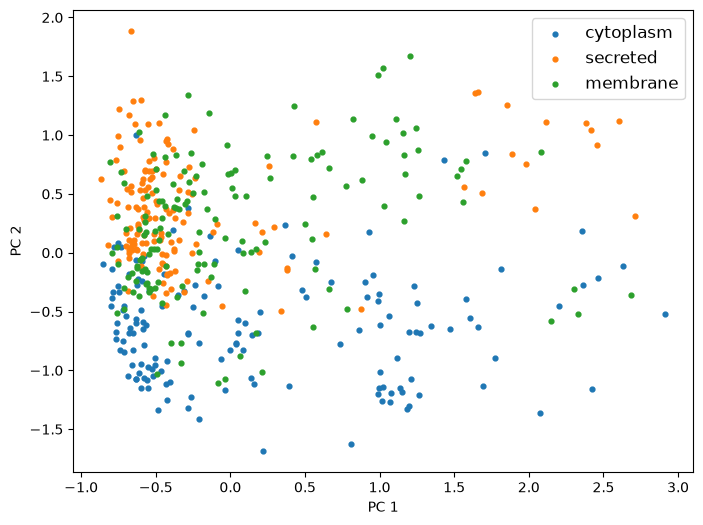

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(prot_vecs)
print('variance explained by 2 components:', np.round(pca.explained_variance_ratio_.sum(), 3))

fig = plt.figure(figsize=(8, 6))
ax = fig.subplots(1)
for loc, color in [('cytoplasm', 'tab:blue'), ('secreted', 'tab:orange'), ('membrane', 'tab:green')]:
    m = proteins['location'] == loc
    ax.scatter(coords[m, 0], coords[m, 1], s=12, c=color, label=loc)
ax.legend(fontsize=12); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2');

The three classes are visibly (if imperfectly) organized in the projection. This is despite never directly providing that information during training.

**UMAP** is a popular nonlinear alternative that often produces more separated, more legible pictures.  It is also easier to over-interpret. In a UMAP plot, distances *between* clusters are close to meaningless, and changing its settings changes the picture.  It is worth seeing both.  (If `umap-learn` is not installed, this cell reports that and moves on — nothing later depends on it.)

Running the UMAP cell typically prints two *warnings* in orange/red text.  One says `n_jobs value 1 overridden` — because we set `random_state` for reproducibility, umap runs single-threaded; with 450 points that costs nothing, and getting the same picture on every machine is worth more.  The other is an informational `OMP` line from a library underneath umap.  **A warning is not an error**: the cell's result is still valid.  Part of working comfortably in scientific Python is learning to read colored text calmly — errors stop the cell, warnings do not.

/opt/miniconda3/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


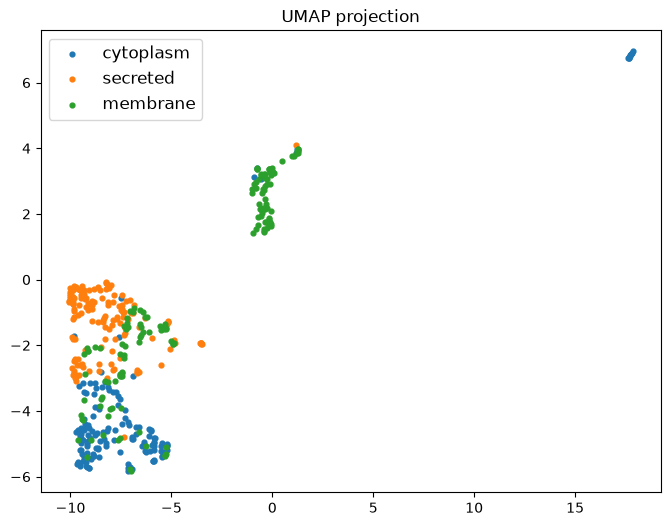

In [7]:
try:
    import umap
    coords_u = umap.UMAP(n_components=2, random_state=0).fit_transform(prot_vecs)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.subplots(1)
    for loc, color in [('cytoplasm', 'tab:blue'), ('secreted', 'tab:orange'), ('membrane', 'tab:green')]:
        m = (proteins['location'] == loc).to_numpy()
        ax.scatter(coords_u[m, 0], coords_u[m, 1], s=12, c=color, label=loc)
    ax.legend(fontsize=12); ax.set_title('UMAP projection')
except ImportError as e:
    print('umap could not be imported. The actual error was:')
    print('   ', e)
    print('If umap-learn was installed while this notebook was running:')
    print('    Kernel -> Restart Kernel, then re-run the notebook from the top.')

<a id="rsa"></a>

## 7. Comparing distance matrices

Nearest neighbors examine one entity at a time. And PCA and UMAP visualizations are nice, but not quantitative numbers we can use to make formal decisions. A more global question: **what organizes this space as a whole, and can we quantify it?**

A standard technique is to compute the full matrix of pairwise distances in the embedding space. Then, compute the same-shaped matrix from some *reference* measure of similarity, and correlate the two.  In neuroscience this technique is called **representational similarity analysis (RSA)**. The same technique appears across fields under different names.  Its power is that the two similarity measures can come from completely different sources: a model and a brain, a model and a behavioral experiment, two different models.

Below, the embedding geometry is compared against two simple sequence-based references:
1) amino-acid **composition** similarity (what fraction of each letter a sequence contains)
2) **3-mer** similarity (overlap in three-letter subsequences)

In [8]:
from scipy.stats import spearmanr
from collections import Counter

def kmer_similarity(seqs, k):
    counts = [Counter(s[i:i+k] for i in range(len(s)-k+1)) for s in seqs]
    vocab = sorted(set().union(*[set(c) for c in counts]))
    kix = {km: j for j, km in enumerate(vocab)}
    M = np.zeros((len(seqs), len(vocab)), dtype=np.float32)
    for r, c in enumerate(counts):
        for km, v in c.items():
            M[r, kix[km]] = v
    M /= np.linalg.norm(M, axis=1, keepdims=True)
    return M @ M.T

emb_cond = pdist(prot_vecs, 'cosine')
comp_sim = kmer_similarity(proteins['sequence'], k=1)
kmer3_sim = kmer_similarity(proteins['sequence'], k=3)

for name, S in [('composition (1-mer)', comp_sim), ('3-mer overlap', kmer3_sim)]:
    r = spearmanr(emb_cond, squareform(1 - S, checks=False)).statistic
    print(f'embedding distance vs {name}:  spearman r = {r:.3f}')

embedding distance vs composition (1-mer):  spearman r = 0.319
embedding distance vs 3-mer overlap:  spearman r = 0.060


Interpretation: the embedding space is *partly* predictable in terms of amino-acid composition (r ≈ 0.32), and almost not at all by raw 3-mer overlap (r ≈ 0.06).  Most of the geometry is something richer than either. We look at this directly in the next section. And tomorrow's session will show us that a simple composition baseline cannot match it.

<a id="probes"></a>

## 8. Linear probes

The most direct question that can be asked of an embedding space representation: **does it contain information about a variable we care about?**

The standard test is a **linear probe**. We freeze the embeddings (they are not retrained). Then fit the simplest possible classifier, and measure cross-validated accuracy.  If a linear classifier can read the variable out of the space, the information is present — and easily accessible.

In the example below, how well can we predict a protein's location (cytoplasm, secreted, membrane) by its embedding vector?

For readers who run decoding analyses on neural data, this is *exactly* a decoding analysis, with the model's activity in place of brain activity.  It's the same logic and the same methods. It also has the same caveats — including yesterday morning's caveat about related samples.  The dataset's `uniref50` column marks families of related sequences, so the split should keep families together (`GroupKFold`, from this morning):

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score

y = proteins['location'].to_numpy()             # the protein's location: [cytoplasm, secreted, membrane]
families = proteins['uniref50'].to_numpy()      # the protein's family: e.g. UniRef50_Q16613, UniRef50_Q9BR61, ...

acc = cross_val_score(LogisticRegression(max_iter=2000), prot_vecs, y,
                      cv=GroupKFold(5), groups=families).mean()

print(f'linear probe, grouped 5-fold CV: {acc:.3f}   (chance = 0.333)')

linear probe, grouped 5-fold CV: 0.902   (chance = 0.333)


90% accuracy, three-way, from a linear read-out of representations produced by a model that was never told what "secreted" means.  The information was learned from sequence statistics alone.

This one technique — frozen representation, linear probe, honest split — is a critically important reusable pattern from this workshop.  Tomorrow morning, the same probe becomes the centerpiece of a complete, reusable workflow.  Instead of loading embeddings that were computed in advance, we will download the ESM-2 model itself. We will run sequences through it on our own laptops, and extract the representations live.  Then the probe will be run twice, on two different representations of the *same* proteins: the model's embeddings, and a deliberately simple alternative — just the amino-acid composition of each sequence (the same composition measure from Section 7).  We will use the same classifier and the same split. Only the representation will change.  If the model's representation predicts localization better than raw letter frequencies do, that difference is evidence the model learned something real about proteins from sequence alone. That comparison is the main event of tomorrow's session.

<a id="homework"></a>

## Homework

The four functions in `a13pm_hw2.py` package this session's tools for reuse — including, after the workshop, on other embedding spaces.  As before: open the file, delete the `raise RuntimeError` line in each function, and use the check cells below.  The first two are for working on here in session; `embedding_rsa` and `linear_probe` are the take-home.  (`linear_probe` gets reused verbatim in tomorrow's homework — writing it once is the point.)

In [ ]:
import a13pm_hw2, importlib
importlib.reload(a13pm_hw2)
help(a13pm_hw2)

**Check `nearest_neighbors`.**  The five nearest neighbors of IFNA2 should all be interferon-family genes (IFNA...):

In [ ]:
importlib.reload(a13pm_hw2)

idx = a13pm_hw2.nearest_neighbors(prot_vecs, genes.index('IFNA2'), k=5)
found = [genes[j] for j in idx]
print(found, '-> all interferons:', all(g.startswith('IFNA') for g in found))

**Check `project_2d`.**  Expected output:

```
coords: (450, 2)   PC1 spread > PC2 spread: True
```

In [ ]:
importlib.reload(a13pm_hw2)

coords2 = a13pm_hw2.project_2d(prot_vecs, method='pca')
print('coords:', coords2.shape, '  PC1 spread > PC2 spread:', coords2[:, 0].std() > coords2[:, 1].std())

**Check `embedding_rsa`** against the composition similarity from Section 7.  Expected output: `0.319`

In [ ]:
importlib.reload(a13pm_hw2)

print(round(a13pm_hw2.embedding_rsa(prot_vecs, comp_sim), 3))

**Check `linear_probe`.**  Expected output: `0.902`

In [ ]:
importlib.reload(a13pm_hw2)

print(round(a13pm_hw2.linear_probe(prot_vecs, y, groups=families), 3))

<a id="summary"></a>

## Summary

An embedding is a learned coordinate system in which distance is meaningful. The process that produces an embedding — similar contexts, similar vectors — applies to any entities that occur in contexts.  Once an embedding space exists, we can use four tools to interrogate it: 
1) **nearest neighbors**: who is close?
2) **projection**: what does the whole space look like?
3) **distance-matrix comparison**: what organizes it?
4) **linear probes** what information does it contain?

The embeddings used today came from a model someone else trained, at someone else's expense.  Tomorrow's sessions extend this to state of the art AI models. We will discuss what foundation models are, how representations are extracted from them on an ordinary laptop, and how the results can deceive.